Checking language type distribution in existing pretraining corpora

In [1]:
import os
import pandas as pd
import tiktoken
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from huggingface_hub import HfApi, hf_hub_download

tqdm.pandas()

FONT_SIZES = {"small": 14, "medium": 18, "large": 24}

PLOT_PARAMS = {
    "font.family": "serif",
    "font.serif": ["Times"],
    "font.size": FONT_SIZES.get("medium"),
    "axes.titlesize": FONT_SIZES.get("large"),
    "axes.labelsize": FONT_SIZES.get("large"),
    "xtick.labelsize": FONT_SIZES.get("large"),
    "ytick.labelsize": FONT_SIZES.get("large"),
    "legend.fontsize": FONT_SIZES.get("medium"),
    "figure.titlesize": FONT_SIZES.get("medium"),
    "text.usetex": True,
}

plt.rcParams.update(PLOT_PARAMS)

/Users/ljvmiranda/Developer/scratch/2026-03-20-madlad/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def load_madlad(lang: str, split: str = "clean_docs") -> pd.DataFrame:
    """Load MADLAD-400 data for a given language code into a DataFrame.

    Args:
        lang: Language code (e.g. 'ceb', 'tgl', 'en').
        split: Which split to load — 'clean_docs', 'noisy_docs', or 'all'.
    """
    api = HfApi()
    files = api.list_repo_tree(
        "allenai/MADLAD-400",
        path_in_repo=f"data-v1p5/{lang}",
        repo_type="dataset",
    )

    local_dir = f"data/{lang}"
    os.makedirs(local_dir, exist_ok=True)

    paths = []
    for f in files:
        if not f.rfilename.endswith(".jsonl.gz"):
            continue
        if split != "all" and split not in f.rfilename:
            continue
        path = hf_hub_download(
            "allenai/MADLAD-400",
            filename=f.rfilename,
            repo_type="dataset",
            local_dir=local_dir,
        )
        paths.append(path)

    print(f"Downloaded {len(paths)} files for '{lang}'")
    return pd.concat([pd.read_json(p, lines=True) for p in paths], ignore_index=True)

In [3]:
df = load_madlad("ceb", split="clean_docs")
df.head(5)

Downloaded 10 files for 'ceb'


,text,timestamp,url
0,Ang Brand Africa nga nagpadayon sa pagsugat sa...,2021-09-24 00:24:28+00:00,https://ceb.eturbonews.com/165852/brand-africa...
1,"Gipalihok pinaagi sa Hiyas sa pagtugnaw, pagla...",2022-05-22 18:13:01+00:00,https://cleverplus.news/news/1409-ya_no_vayas_...
2,Ang Apple adunay labing kapuslan nga mga tinda...,2021-09-26 04:32:23+00:00,https://www.soydemac.com/ceb/apple-ang-labing-...
3,Hotels.com helps you to find the best hotel fo...,2021-11-27 03:08:03+00:00,https://sg.hotels.com/de700471/ugento-italy-ho...
4,Purohan batok COVID-19 | Banat\nPurohan batok ...,2020-11-28 12:00:41+00:00,https://www.philstar.com/banat/opinyon/2020/06...


Before we do some fun stuff, might be nice to just learn more about the data

In [4]:
enc = tiktoken.get_encoding("cl100k_base")
df["token_length"] = df["text"].progress_apply(lambda x: len(enc.encode(x)))

100%|██████████| 66164/66164 [00:22<00:00, 2881.34it/s]


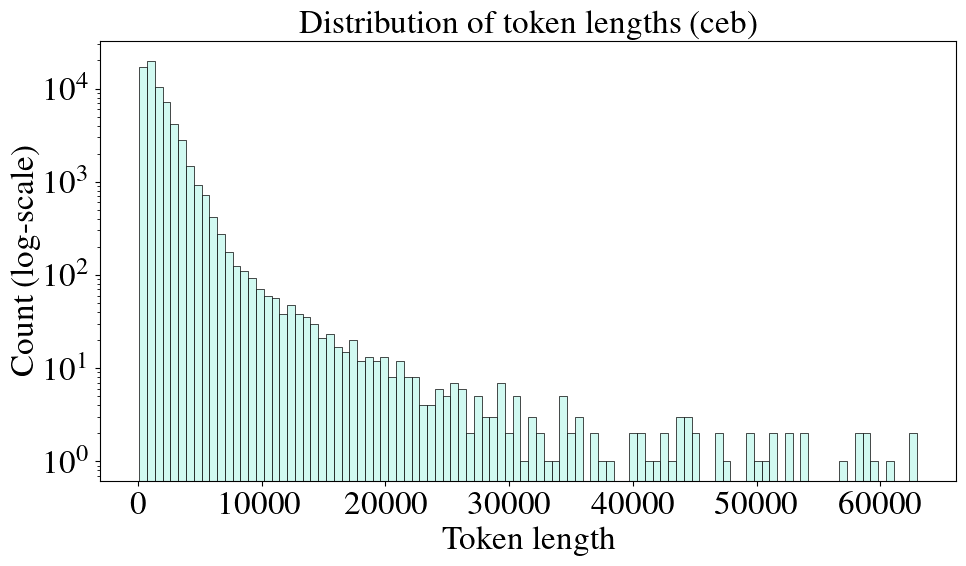

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df["token_length"], bins=100, color="#D1F9F1", edgecolor="black", linewidth=0.5)
ax.set_yscale("log")
ax.set_xlabel("Token length")
ax.set_ylabel("Count (log-scale)")
ax.set_title("Distribution of token lengths (ceb)")
fig.tight_layout()
plt.show()

Ideally, I'd check each text and confirm which data type they have. But assuming I don't have any knowledge about the language, what can I do? Maybe...

- Check the URLs? Perhaps there's a way to cross-reference URLs to a certain domain.
- Use an LLM? Maybe something like [this work](https://arxiv.org/pdf/2502.10341). But how do you validate this?

Let's start by checking the URLs

In [6]:
from urllib.parse import urlparse

df["tld"] = df["url"].apply(lambda x: "." + urlparse(x).netloc.rsplit(".", 1)[-1])

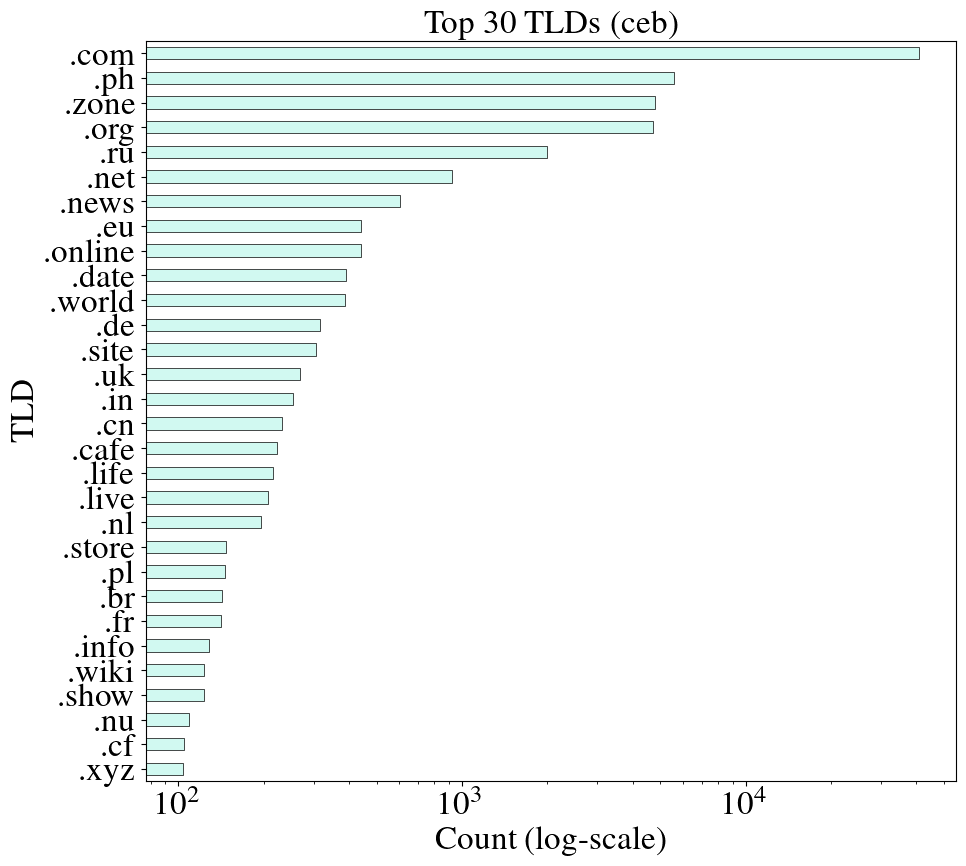

In [7]:
top_n = 30
tld_counts = df["tld"].value_counts().head(top_n)

fig, ax = plt.subplots(figsize=(10, 9))
tld_counts.plot.barh(ax=ax, color="#D1F9F1", edgecolor="black", linewidth=0.5)
ax.invert_yaxis()
ax.set_xscale("log")
ax.set_xlabel("Count (log-scale)")
ax.set_ylabel("TLD")
ax.set_title(f"Top {top_n} TLDs (ceb)")
fig.tight_layout()
plt.show()

### Topic classification

Using [WebOrganizer/TopicClassifier](https://huggingface.co/WebOrganizer/TopicClassifier) to classify documents into 24 topic categories.

In [13]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

TOPIC_LABELS = {
    0: "Adult",
    1: "Art & Design",
    2: "Software Dev.",
    3: "Crime & Law",
    4: "Education & Jobs",
    5: "Hardware",
    6: "Entertainment",
    7: "Social Life",
    8: "Fashion & Beauty",
    9: "Finance & Business",
    10: "Food & Dining",
    11: "Games",
    12: "Health",
    13: "History",
    14: "Home & Hobbies",
    15: "Industrial",
    16: "Literature",
    17: "Politics",
    18: "Religion",
    19: "Science & Tech.",
    20: "Software",
    21: "Sports & Fitness",
    22: "Transportation",
    23: "Travel",
}

device = torch.device("cpu")

topic_tokenizer = AutoTokenizer.from_pretrained("WebOrganizer/TopicClassifier")
topic_model = (
    AutoModelForSequenceClassification.from_pretrained(
        "WebOrganizer/TopicClassifier",
        trust_remote_code=True,
        use_memory_efficient_attention=False,
        torch_dtype=torch.float32,
    )
    .to(device)
    .eval()
)

Loading weights: 100%|██████████| 139/139 [00:00<00:00, 16686.94it/s]


In [16]:
@torch.no_grad()
def classify_topic(text: str, url: str = "") -> str:
    """Classify a single document into one of 24 topic categories."""
    input_text = f"{url}\n\n{text}" if url else text
    inputs = topic_tokenizer([input_text], return_tensors="pt", truncation=True).to(
        device
    )
    seq_len = inputs["input_ids"].shape[1]
    inputs["position_ids"] = torch.arange(
        seq_len, dtype=torch.long, device=device
    ).unsqueeze(0)
    outputs = topic_model(**inputs)
    pred = outputs.logits.softmax(dim=-1).argmax(dim=-1).item()
    return TOPIC_LABELS[pred]


# Quick test
print("{url}\nn{text}".format(url=df["url"].iloc[0], text=df["text"].iloc[0]))
classify_topic(df["text"].iloc[0], df["url"].iloc[0])

https://ceb.eturbonews.com/165852/brand-africa-nga-nagpadayon-sa-unahan-sa-zambia-nagtagbo-sa-mga-asosasyon-sa-pagdumala-sa-pantalan/
nAng Brand Africa nga nagpadayon sa pagsugat sa Zambia sa Ports Management Association\nHome » Pinakabag-ong Mga Artikulo sa Balita » Mga Kasayuran nga Balita » Ang Brand Africa nga nagpadayon sa pagsugat sa Zambia sa Ports Management Association\nMga Kasayuran nga Balita • Pagbungkag sa Balita sa Pagbiyahe • Pag-cruis • Balita • Turismo • Transportation • Pagbag-o sa Destinasyon sa Pagbiyahe • Balita sa Travel Wire • Balita sa Pagbungkag sa Zambia\nAng Ministro sa Turismo ug Sining nga si Hon. Gisulti ni Charles Banda nga ang Zambia sa dili madugay makita kung unsa ang labing kaayo aron mapalambo ang turismo sa cruise pinaagi sa paggamit sa mga magamit nga mga tubig nga tubig ingon ang Seychelles 'Head of Mission sa Zambia, si Jamil (Jimmy) Butt, nagsulti nga ang iyang nasud gusto nga magtubo ang usa ka bilateral nga panaghigalaay sa linya sa Kasabutan 

'Adult'

In [20]:
df_sample = df.sample(100)
df_sample["topic"] = df_sample.progress_apply(
    lambda row: classify_topic(row["text"], row["url"]), axis=1
)

100%|██████████| 100/100 [00:41<00:00,  2.43it/s]


In [31]:
def inspect_topic(df: pd.DataFrame, topic: str, n: int = 5) -> pd.DataFrame:
    """Sample n rows from a given topic and display text snippets."""
    subset = df[df["topic"] == topic]
    sample = subset.sample(min(n, len(subset)))
    for _, row in sample.iterrows():
        print(f"[{row['topic']}] {row['url']}")
        print(row["text"][:300])
        print("---")
    return sample


inspect_topic(df_sample, "Health", n=5)

[Health] https://ceb.phcoker.com/meclofenoxate/
Ang Centrophenoxine, nailhan usab nga Meclofenoxate o Centro, usa ka gamhanan nga nootropic nga butang nga lakip sa pinakauna ug kaylap nga gipanukiduki nootropics.\nGipamaligya kini ingon nga reseta nga gireseta sa ngalan sa brand, ang Lucidril® sa pipila ka mga nasud ug ingon usab usa ka suplement
---
[Health] http://newsrule.com/ceb/does-alcohol-really-make-you-better-in-bed/
Ba alkohol sa tinuod paghimo kaninyo nga mas maayo sa higdaanan? - News Lagda\nHome & Tanaman\nTerms Sa Paggamit\nlabing maayo nga Smartphone 2019\nBa alkohol sa tinuod paghimo kaninyo nga mas maayo sa higdaanan?\nKini nga artikulo nga giulohan og “Ba alkohol sa tinuod paghimo kaninyo nga mas maayo 
---
[Health] http://cebuano.thyroid.ph/unsa-ang-hyperthyroidism4.html
Unsa ang hyperthyroidism4\nUnsay tambal sa hyperthyroidism?\nWala laing tambal sa hyperthyroidism . Ang sakto nga pagtambal kay mahibaloan pina-agi sa pagkahibaw sa hinungdan sa hyperthyroidism, edad

,text,timestamp,url,token_length,tld,topic
2891,"Ang Centrophenoxine, nailhan usab nga Meclofen...",2020-09-22 05:43:58+00:00,https://ceb.phcoker.com/meclofenoxate/,5526,.com,Health
45932,Ba alkohol sa tinuod paghimo kaninyo nga mas m...,2020-09-27 02:48:29+00:00,http://newsrule.com/ceb/does-alcohol-really-ma...,3749,.com,Health
34555,Unsa ang hyperthyroidism4\nUnsay tambal sa hyp...,2019-03-22 21:20:15+00:00,http://cebuano.thyroid.ph/unsa-ang-hyperthyroi...,301,.ph,Health
5371,"Published: Wednesday, 25 March 2020 08:34\nWri...",2020-12-02 19:39:38+00:00,http://davaodelnorte.gov.ph/index.php/news/948...,491,.ph,Health
35434,Cebuano News: PGMA nag abi-abi sa Nobel winner...,2020-08-14 23:00:50+00:00,http://archives.pia.gov.ph/?m=12&fi=p100202.ht...,472,.ph,Health


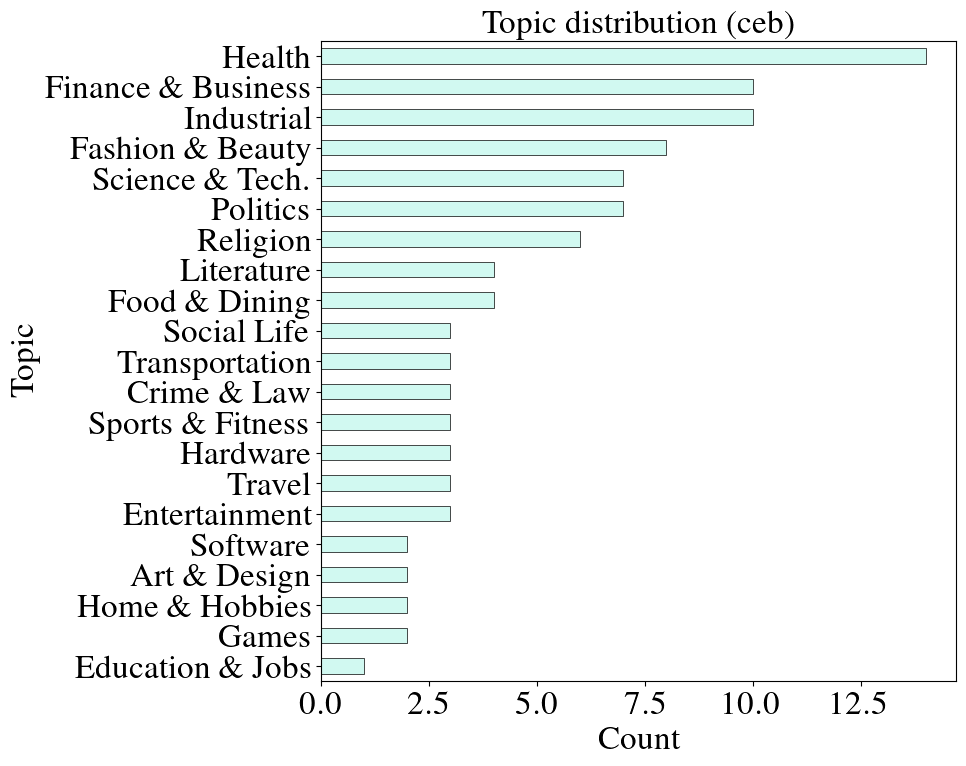

In [ ]:
topic_counts = df_sample["topic"].value_counts()

fig, ax = plt.subplots(figsize=(10, 8))
topic_counts.plot.barh(ax=ax, color="#D1F9F1", edgecolor="black", linewidth=0.5)
ax.invert_yaxis()
ax.set_yticklabels([label.replace("&", r"\&") for label in topic_counts.index])
ax.set_xlabel("Count")
ax.set_ylabel("Topic")
ax.set_title(f"Topic distribution (ceb), \# of samples = {len(df_sample)}")
fig.tight_layout()
plt.show()